In [399]:
import pandas as pd
import numpy as np

bars_df = pd.read_parquet("../data/bars_seen_train.parquet")
unseen_bars_df = pd.read_parquet("../data/bars_unseen_train.parquet")
sentiment_df = pd.read_csv("../sentiment_overview.csv")
headlines_df_seen = pd.read_parquet("../data/headlines_seen_train.parquet")
headlines_df_unseen = pd.read_parquet("../data/headlines_unseen_train.parquet")

print(sentiment_df.head())
print(bars_df.head())

   session                headline  bar_ix decided_label  prob_positive  \
0        0      Relvos Biosciences       6       neutral       0.387032   
1        0       Orevex Renewables      12      positive       0.948091   
2        0      Relvos Biosciences      14       neutral       0.061307   
3        0         Calvis Sciences      20      positive       0.945060   
4        0  Yorvov Pharmaceuticals      22      positive       0.947761   

   prob_negative  prob_neutral  linear_score  polarity_score  cluster  
0       0.013454      0.599514      0.373578        0.932811        0  
1       0.012295      0.039614      0.935795        0.974395        1  
2       0.040272      0.898421      0.021034        0.207074        0  
3       0.010088      0.044852      0.934971        0.978876        0  
4       0.012083      0.040155      0.935678        0.974823        0  
   bar_ix  session  open    high     low   close
0       0        0   1.0  1.0029  0.9986  0.9999
1       0        1 

Relvos Biosciences opens new office in Southeast Asia
6
Orevex Renewables secures $500M contract with a global retailer
12
Relvos Biosciences names new head of precision manufacturing division
14
Calvis Sciences secures $650M contract with a leading cloud platform
20
Yorvov Pharmaceuticals secures $180M contract with a national infrastructure agency
22
Relvos Biosciences reports 3% decline in operating income
26
Relvos Biosciences secures $320M contract with a leading cloud platform
26
Calvis Sciences expands operations into Asia Pacific markets
33
Yorvov Pharmaceuticals sees mixed results in supply chain optimization pilot program
44
Orevex Renewables secures $650M contract with a major logistics provider
47
Orevex Renewables faces class action over automated logistics service disruption
48
Orevex Renewables begins scheduled maintenance of enterprise software systems
51
hello
Yorvov Pharmaceuticals secures $120M contract with a multinational manufacturer
53
hello
Relvos Biosciences se

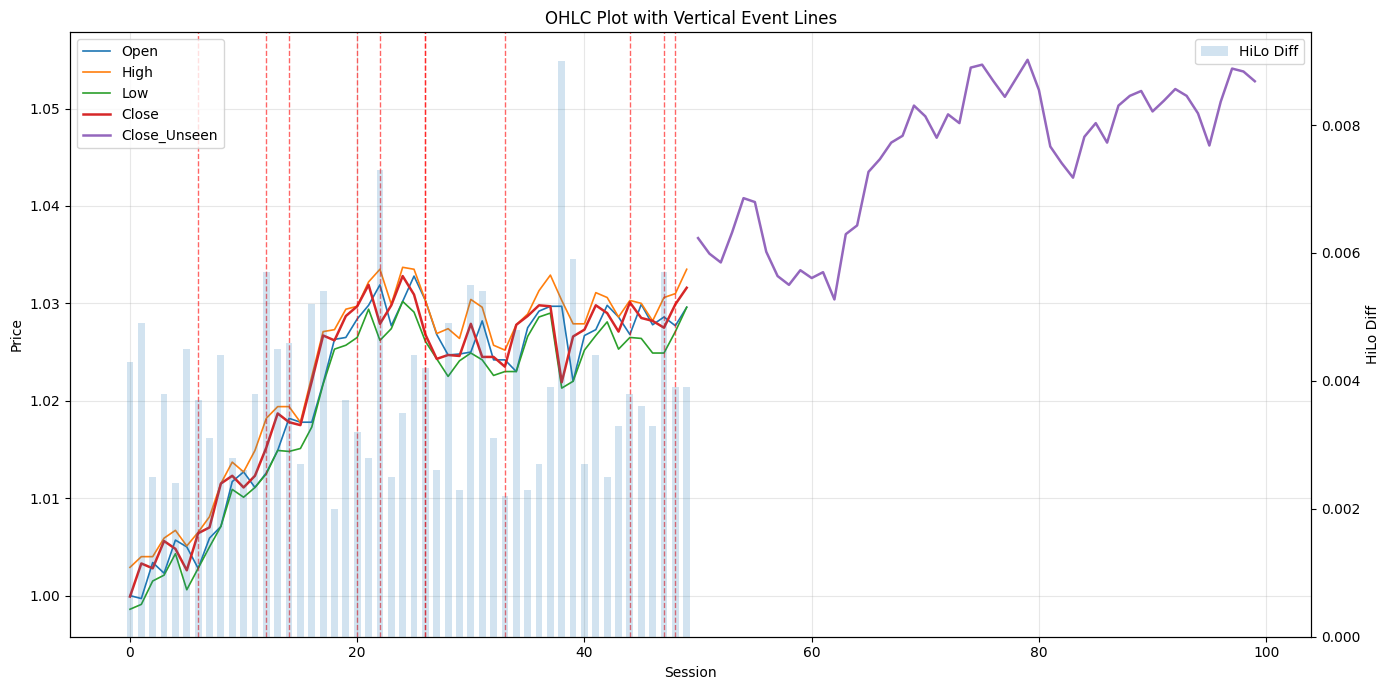

In [400]:
session_of_interest = 0

import pandas as pd
import matplotlib.pyplot as plt

# df  = main dataframe with OHLC data
# df2 = second dataframe containing bar_ix values where vertical lines should be drawn

# Example:
# df2 = pd.DataFrame({"bar_ix": [5, 12, 18, 33, 41]})

df = bars_df[bars_df["session"] == session_of_interest]
df["hilo_diff"] = df["high"] - df["low"]
df2 = sentiment_df[sentiment_df["session"] == session_of_interest]
df_unseen = unseen_bars_df[unseen_bars_df["session"] == session_of_interest]
headlines_df_seen = headlines_df_seen[headlines_df_seen["session"] == session_of_interest]
headlines_df_unseen = headlines_df_unseen[headlines_df_unseen["session"] == session_of_interest]
# print(headlines_df_seen)

for idx, row in headlines_df_seen.iterrows():
    print(row.headline)
    print(row.bar_ix)

for idx, row in headlines_df_unseen.iterrows():
    print(row.headline)
    print(row.bar_ix)
    print("hello")
# print(headlines_df_unseen)

fig, ax1 = plt.subplots(figsize=(14, 7))

# Main OHLC lines
ax1.plot(df["bar_ix"], df["open"],  label="Open", linewidth=1.2)
ax1.plot(df["bar_ix"], df["high"],  label="High", linewidth=1.2)
ax1.plot(df["bar_ix"], df["low"],   label="Low", linewidth=1.2)
ax1.plot(df["bar_ix"], df["close"], label="Close", linewidth=1.8)
ax1.plot(df_unseen["bar_ix"], df_unseen["close"], label="Close_Unseen", linewidth=1.8)

# Add vertical lines at bar_ix positions from df2
for x in df2["bar_ix"]:
    ax1.axvline(x=x, linestyle="--", linewidth=1, alpha=0.6, color="red")

# Secondary axis for hilo_diff
ax2 = ax1.twinx()
ax2.bar(df["bar_ix"], df["hilo_diff"], alpha=0.2, width=0.6, label="HiLo Diff")

# Labels
ax1.set_xlabel("Session")
ax1.set_ylabel("Price")
ax2.set_ylabel("HiLo Diff")

# Title
plt.title("OHLC Plot with Vertical Event Lines")

# Legend
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

# Grid
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [401]:
def do_single_session(session_of_interest=2):
    df = bars_df[bars_df["session"] == session_of_interest].copy()

    df["hilo_diff"] = df["high"] - df["low"]

    df2 = sentiment_df[sentiment_df["session"] == session_of_interest].copy()

    result = pd.merge(df, df2, on="bar_ix", how="inner")

    only_volatility = result[["bar_ix","headline", "hilo_diff", "prob_positive", "prob_negative", "prob_neutral"]].sort_values(
        by="bar_ix",
        ascending=False   # highest first
    )

    print(only_volatility)

    # candidate_a = only_volatility[only_volatility["headline"] == "Zrovex Industries"]
    # candidate_b = only_volatility[only_volatility["headline"] == "Jorvis Fuels"]
    return (0, 0)
    return candidate_a, candidate_b

In [402]:
a, b = do_single_session(session_of_interest=session_of_interest)

    bar_ix                headline  hilo_diff  prob_positive  prob_negative  \
10      48       Orevex Renewables     0.0039       0.011351       0.953480   
9       47       Orevex Renewables     0.0057       0.950261       0.013908   
8       44  Yorvov Pharmaceuticals     0.0038       0.026838       0.947266   
7       33         Calvis Sciences     0.0022       0.760141       0.008625   
5       26      Relvos Biosciences     0.0042       0.008312       0.974797   
6       26      Relvos Biosciences     0.0042       0.948155       0.012102   
4       22  Yorvov Pharmaceuticals     0.0073       0.947761       0.012083   
3       20         Calvis Sciences     0.0032       0.945060       0.010088   
2       14      Relvos Biosciences     0.0046       0.061307       0.040272   
1       12       Orevex Renewables     0.0057       0.948091       0.012295   
0        6      Relvos Biosciences     0.0037       0.387032       0.013454   

    prob_neutral  
10      0.035169  
9       0.035

In [403]:
a

0

In [404]:
b

0

In [405]:
def identify_firm(session_of_interest=2):
    price_df = bars_df[bars_df["session"] == session_of_interest].copy().copy()
    news_df = sentiment_df[sentiment_df["session"] == session_of_interest].copy()
    news_df = news_df.copy()
    news_df["company"] = news_df["headline"]

    # ---------------------------------------------------------
    # STEP 2: Convert sentiment probabilities into one score
    # positive = +1
    # negative = -1
    # neutral = 0
    # ---------------------------------------------------------
    news_df["sentiment_score"] = (
        news_df["prob_positive"] - news_df["prob_negative"]
    )

    # ---------------------------------------------------------
    # STEP 3: Aggregate sentiment by bar_ix and company
    # ---------------------------------------------------------
    sentiment = (
        news_df.groupby(["company", "bar_ix"], as_index=False)
        .agg(sentiment_score=("sentiment_score", "mean"))
    )

    # ---------------------------------------------------------
    # STEP 4: Daily close price
    # (average close across sessions inside same bar_ix)
    # ---------------------------------------------------------
    daily_px = (
        price_df.groupby("bar_ix", as_index=False)
        .agg(close=("close", "mean"))
        .sort_values("bar_ix")
    )

    # ---------------------------------------------------------
    # STEP 5: FUTURE 5-DAY RETURN
    # price change from today to +5 bars
    # ---------------------------------------------------------
    daily_px["future_close_5d"] = daily_px["close"].shift(-3)

    daily_px["future_ret_5d"] = (
        daily_px["future_close_5d"] - daily_px["close"]
    ) / daily_px["close"]

    price_move = daily_px[["bar_ix", "future_ret_5d"]].dropna()

    # ---------------------------------------------------------
    # STEP 6: Merge each company sentiment with unknown price
    # ---------------------------------------------------------
    merged = sentiment.merge(price_move, on="bar_ix", how="inner")

    # ---------------------------------------------------------
    # STEP 7: Score companies
    # ---------------------------------------------------------
    results = []

    for company, g in merged.groupby("company"):

        if len(g) < 2:
            continue

        corr = g["sentiment_score"].corr(g["future_ret_5d"])

        sent_sign = np.sign(g["sentiment_score"])
        px_sign   = np.sign(g["future_ret_5d"])

        hitrate = (sent_sign == px_sign).mean()

        # stronger weight on correlation
        score = 0.75 * corr + 0.25 * hitrate

        results.append({
            "company": company,
            "n_obs": len(g),
            "corr_5d": corr,
            "hitrate_5d": hitrate,
            "score": score
        })

    results_df = (
        pd.DataFrame(results)
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )

    print(results_df)
    return results_df

results_df = identify_firm(session_of_interest=session_of_interest)

                  company  n_obs   corr_5d  hitrate_5d     score
0  Yorvov Pharmaceuticals      2  1.000000         1.0  1.000000
1      Relvos Biosciences      3  0.342692         1.0  0.507019
2         Calvis Sciences      2 -1.000000         1.0 -0.500000


In [406]:
firm_of_interest = results_df["company"][0]
print(firm_of_interest)

Yorvov Pharmaceuticals


In [407]:
def only_headlines_sentiment(session_of_interest, firm_of_interest):
    price_df = bars_df[bars_df["session"] == session_of_interest].copy().copy()
    news_df = sentiment_df[sentiment_df["session"] == session_of_interest].copy()
    news_df = news_df[news_df["headline"] == firm_of_interest]
    news_df = news_df.copy()
    print(news_df)
    return news_df
    
filterned_news_df = only_headlines_sentiment(session_of_interest, firm_of_interest)

   session                headline  bar_ix decided_label  prob_positive  \
4        0  Yorvov Pharmaceuticals      22      positive       0.947761   
8        0  Yorvov Pharmaceuticals      44      negative       0.026838   

   prob_negative  prob_neutral  linear_score  polarity_score  cluster  
4       0.012083      0.040155      0.935678        0.974823        0  
8       0.947266      0.025896     -0.920428       -0.944897        0  


In [408]:
def get_sizing():

    DECAY_LAMBDA = 0.15     # staleness decay rate
    THRESHOLD = 0.05        # no-trade zone
    MAX_LEVERAGE = 2.0      # cap position size

    # -----------------------------
    # 2. SORT DATA
    # -----------------------------
    df = filterned_news_df.sort_values(["session", "bar_ix"]).copy()

    # -----------------------------
    # 3. COMPUTE STALENESS DECAY
    # -----------------------------
    # within each session, compute time since most recent bar
    df["age"] = df.groupby("session")["bar_ix"].transform(
        lambda x: 50 - x
    )

    df["decay"] = np.exp(-DECAY_LAMBDA * df["age"])

    # -----------------------------
    # 4. EFFECTIVE SENTIMENT SIGNAL
    # -----------------------------
    df["effective_signal"] = df["linear_score"] * df["decay"]

    # -----------------------------
    # 5. AGGREGATE PER BAR (important)
    # -----------------------------
    agg = (
        df.groupby(["session", "bar_ix"], as_index=False)
        .agg({
            "effective_signal": "sum",
            "linear_score": "mean",
            "decay": "mean"
        })
    )

    # -----------------------------
    # 6. VOLATILITY PROXY
    # -----------------------------
    # simple rolling std of signal per session
    agg["volatility"] = (
        agg.groupby("session")["effective_signal"]
        .transform(lambda x: x.rolling(5, min_periods=1).std().fillna(1e-3))
    )

    # -----------------------------
    # 7. NORMALIZED TRADE SIGNAL
    # -----------------------------
    agg["raw_signal"] = agg["effective_signal"] / agg["volatility"]

    # -----------------------------
    # 8. POSITION SIZING FUNCTION
    # -----------------------------
    def size_position(x):
        if abs(x) < THRESHOLD:
            return 0.0
        return np.clip(x, -MAX_LEVERAGE, MAX_LEVERAGE)

    agg["position"] = agg["raw_signal"].apply(size_position)

    # -----------------------------
    # 9. TRADE DIRECTION
    # -----------------------------
    agg["direction"] = np.sign(agg["position"])

    # -----------------------------
    # 10. FINAL OUTPUT
    # -----------------------------
    result = agg[[
        "session",
        "bar_ix",
        "effective_signal",
        "raw_signal",
        "position",
        "direction"
    ]]

    print(result.head())
    return result["effective_signal"].sum()

print(round(get_sizing(), 3))

   session  bar_ix  effective_signal  raw_signal  position  direction
0        0      22          0.014031   14.031035  2.000000        1.0
1        0      44         -0.374218   -1.363105 -1.363105       -1.0
-0.36
